# CREATE FIGURE 2 PANELS
## last updated: 08.01.25

In [7]:
%run "ecDNAInspector_functions.ipynb"

In [8]:
import numpy as np
import pandas as pd

In [2]:
# creates figure 2a
# figure 2a displays the sorted consensus clustering result of ecDNAInspector applied to the IC-subtyped Breast Cohort

In [9]:
# load path to cycle-level data table with cluster & confidence assignment included
cycle_level_data_table = 'full_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_table)

In [10]:
# modify or add any features
cohort_df["Cycle Type Boolean"] = (cohort_df["Cycle Type"] == "circular").astype(int)

In [11]:
clustering_features = ["Cycle TPR", "Cycle FPR", "Cycle PFNR", "Cycle MEB"]
boolean_metrics = ["Cycle Type Boolean", "Cycle ESB"]
size_metric = ["Cycle Size (bp)"]
structural_metrics = ["Cycle Breakpoint Count", "Cycle Chromosome Count"]

cluster_feature_labels = ["TPR", "FPR", "PFNR", "MEB"]
boolean_metric_labels = ["Cycle Type", "ESB"]
size_metric_labels = ["Cycle Size (bp)"]
structural_metric_labels = ["BP Count", "Chrom. Count"]

sorting_features = ['Cycle Cluster Assignment', 'Cycle Type Boolean', 'Cycle TPR']
sorting_features_dir = [True, False, False]

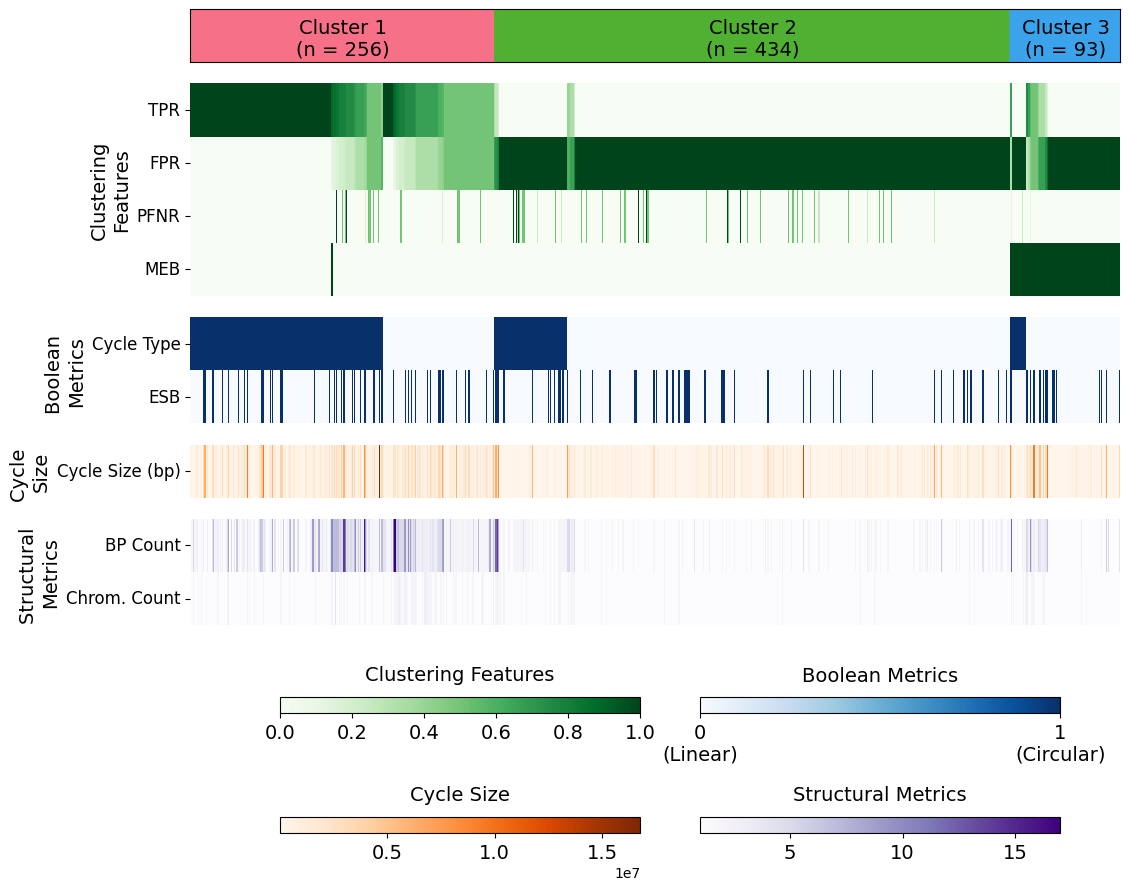

In [12]:
plot_separated_clustering_heatmap(cohort_df, 
                                  clustering_features, boolean_metrics, size_metric, structural_metrics, 
                                  cluster_feature_labels, boolean_metric_labels, size_metric_labels, structural_metric_labels,
                                  sorting_features, sorting_features_dir)

In [13]:
# creates figure 2d
# figure 2d displays the proportion of cycles within each cluster belonging to the high, medium, or low confidence bucket

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_41120/3447879020.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  new_labels = [f"{label}\n(n={group_sizes[label]})" for label in proportions.index]


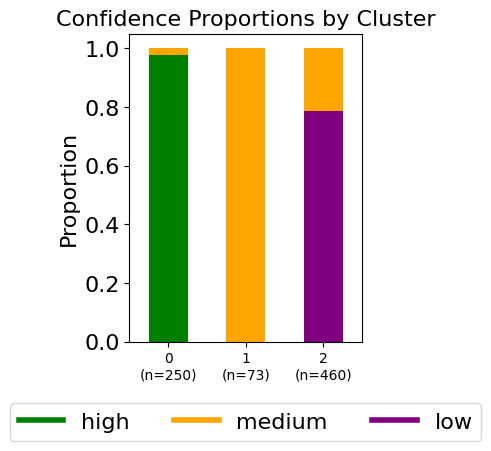

In [14]:
group = "Cycle Cluster Assignment"
metric = "Confidence"
colors = {"high": "green", "medium": "orange", "low": "purple"}
labels = ["Cluster 1", "Cluster 2", "Cluster 3"]
legend_order = ["high", "medium", "low"]
fontsize = 16
legend_title_fontsize = 16
figsize = (3, 4)
title = "Confidence Proportions by Cluster"
legend_ncol = 3

proportions = cohort_df.groupby([group, metric]).size().unstack(fill_value=0)
proportions = proportions.div(proportions.sum(axis=1), axis=0)

group_sizes = cohort_df.groupby('Confidence').size()

color_list = [colors.get(col, '#333333') for col in proportions.columns]  # Default to gray if not found

ax = proportions.plot(kind='bar', stacked=True, color=color_list, figsize=figsize)

new_labels = [f"{label}\n(n={group_sizes[label]})" for label in proportions.index]
ax.set_xticks(range(len(new_labels)))
ax.set_xticklabels(new_labels, rotation=0)
plt.yticks(fontsize=fontsize)
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Proportion', fontsize=fontsize)
plt.title(title, fontsize=fontsize)
handles = [plt.Line2D([0], [0], color=colors.get(cat, '#333333'), lw=4) for cat in legend_order]
ax.legend(handles=handles, title=None, bbox_to_anchor=(0.5, -0.2), loc='upper center', borderaxespad=0., fontsize=fontsize, title_fontsize=legend_title_fontsize, labels=legend_order, ncol=legend_ncol)

plt.show()

In [15]:
# creates figure 2e
# figure 2e displays the proportion of circular or linear cycles in the high, medium, and low confidence groups

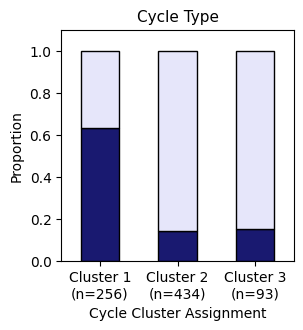

In [20]:
group_sizes = cohort_df.groupby('Cycle Cluster Assignment').size()

proportions = cohort_df.groupby('Cycle Cluster Assignment')['Cycle Type'].value_counts(normalize=True).unstack(fill_value=0)

cluster_order = [0, 1, 2]

proportions = proportions.loc[cluster_order]
proportions = proportions[["circular", "linear"]]

fig, ax = plt.subplots(figsize=(3, 3))
ax = proportions.plot(kind='bar', stacked=True, color=['midnightblue', 'lavender'], edgecolor='black', ax=ax)

new_labels = [f"Cluster {label + 1}\n(n={group_sizes[label]})" for label in proportions.index]

ax.set_xticks(range(len(new_labels)))
ax.set_xticklabels(new_labels, rotation=0)

plt.xlabel("Cycle Cluster Assignment")
plt.ylabel('Proportion')
ax.legend_.remove()
plt.ylim(0, 1.1)

plt.title("Cycle Type", fontsize=11)

plt.show()

In [21]:
# Perform Chi-squared test
contingency_table = cohort_df.pivot_table(index='Cycle Cluster Assignment', 
                                          columns='Cycle Type', 
                                          aggfunc='size', 
                                          fill_value=0)

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

# effect size calculation (Cramer's V)
n = contingency_table.sum().sum()
k = contingency_table.shape[1]
r = contingency_table.shape[0]

cramers_v = np.sqrt(chi2_stat / (n * min(k - 1, r - 1)))

print(f"p = {p_value}")
print(f"Cramer's V = {cramers_v}")

p = 2.208434242618647e-43
Cramer's V = 0.5008775829052382


In [ ]:
# creates figure 2f
# figure 2f displays the proportion of high, medium, and low confidence cycles from HER2+ patients containing ERBB2

In [22]:
# load file with information about IC subtype of samples
subtype_info = 'full_tool_testing/BCarc_eniclust.csv'
subtype_df = pd.read_csv(subtype_info)
merged_df = pd.merge(cohort_df, subtype_df, on="Sample", how="left")

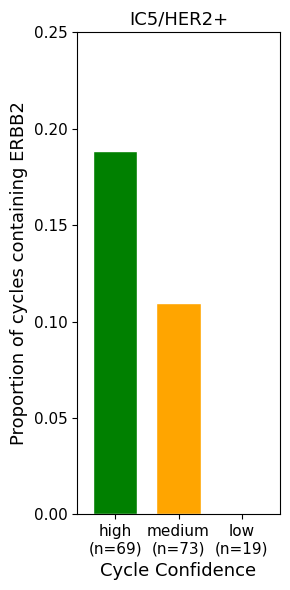

In [23]:
#subset to IC5/HER2+ samples only
ic5_subset = merged_df[merged_df['ENiClust'] == 'ic5']

confidence_order = ['high', 'medium', 'low']
proportions = (
    ic5_subset.groupby('Confidence')['Cycle Genes List']
    .apply(lambda genes: genes.apply(lambda x: 'ERBB2' in x).mean())  # Proportion of rows containing "ERBB2"
    .reindex(confidence_order)  # Ensure the confidence levels are ordered
    .fillna(0)  # Fill missing levels with 0
)

plt.figure(figsize=(3, 6))
proportions.plot(kind='bar', color=['green', 'orange', 'purple'], width=0.7, edgecolor='white')
plt.title('IC5/HER2+', fontsize=13)
plt.ylabel('Proportion of cycles containing ERBB2', fontsize=13)
custom_labels = ['high\n(n=69)', 'medium\n(n=73)', 'low\n(n=19)']
plt.xticks(ticks=range(len(custom_labels)), labels=custom_labels, rotation=0, fontsize=11)
plt.xlabel('Cycle Confidence', fontsize=13)
plt.yticks(rotation=0, fontsize=11)
plt.ylim(0, 0.25)
plt.tight_layout()

plt.show()